<a href="https://colab.research.google.com/github/sadaftabasarman/week5_lab/blob/main/Sadaf_Arman_Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentals of Machine Learning

## Lab: Multiple Linear Regression and Polynomial Regression with Feature Scaling

**Duration:** 2 hours

| Part | What happens | Time |
|---|---|---|
| Part A | Guided walkthrough. Follow along and run each cell with the instructor. | about 60 minutes |
| Part B | Graded exercises. Work on your own. Total: 100 marks. | about 60 minutes |

**By the end of this lab you should be able to:**

1. Train a linear regression model that uses more than one feature.
2. Explain what feature scaling is and apply it correctly.
3. Fit a curve to data using polynomial regression.
4. Compare models using the R2 score and choose a sensible polynomial degree.

---
# Part A: Guided Walkthrough

## A0. Setup

We import the libraries once at the top.

- `numpy` and `pandas` hold our data.
- `matplotlib` draws plots.
- `sklearn` (scikit-learn) gives us ready-made machine learning tools.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

## A1. Multiple Linear Regression

### The idea

In simple linear regression we predict a value from **one** feature:

$$y = w \cdot x + b$$

In **multiple** linear regression we use **several** features at the same time:

$$y = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$$

- $x_1, x_2, x_3$ are the features (the inputs).
- $w_1, w_2, w_3$ are the **weights** (also called coefficients). Each weight says how much the prediction changes when that feature goes up by 1.
- $b$ is the **intercept** (the starting value when all features are 0).

Training the model means finding the weights and the intercept that give the smallest error.

### Our example: house prices

We want to predict the price of a house from three features:

| Feature | Meaning |
|---|---|
| `area_m2` | area of the house in square metres |
| `rooms` | number of rooms |
| `age_years` | age of the house in years |

The target is `price` (in thousand USD).

We create the data ourselves so that we know the true rule behind it. Then we can check whether the model finds that rule.

In [ ]:
np.random.seed(42)          # makes the random numbers the same every time
n = 200                     # number of houses

area = np.random.uniform(40, 200, n)      # between 40 and 200 square metres
rooms = np.random.randint(1, 6, n)        # 1, 2, 3, 4 or 5 rooms
age = np.random.uniform(0, 40, n)         # between 0 and 40 years
noise = np.random.normal(0, 10, n)        # random variation, like in real life

# The true rule that creates the price
price = 20 + 0.9 * area + 8 * rooms - 0.6 * age + noise

houses = pd.DataFrame({
    "area_m2": area,
    "rooms": rooms,
    "age_years": age,
    "price": price
})

houses.head()

,area_m2,rooms,age_years,price
0,99.926419,4,38.447623,107.032618
1,192.114289,3,36.214026,174.782123
2,157.119031,1,7.831645,162.014072
3,135.785357,4,2.774452,179.717573
4,64.962982,4,4.031120,123.071583


### Step 1: Look at the data

Always look at the data before training a model. `describe()` shows the minimum, maximum and average of every column.

In [ ]:
print("Rows and columns:", houses.shape)
houses.describe()

Rows and columns: (200, 4)


,area_m2,rooms,age_years,price
count,200.000000,200.000000,200.000000,200.000000
mean,117.440997,3.035000,21.321188,136.581881
std,47.182629,1.440189,12.496306,44.044475
min,40.883539,1.000000,0.433506,37.162534
25%,76.573186,2.000000,11.202708,102.294401
50%,119.117801,3.000000,22.386844,131.776524
75%,161.097539,4.000000,32.524980,174.918451
max,197.901910,5.000000,39.988707,219.303952


Notice the **different ranges**: `area_m2` goes up to about 200, while `rooms` only goes from 1 to 5. Remember this. It is the reason we need feature scaling in section A2.

Now we plot each feature against the price.

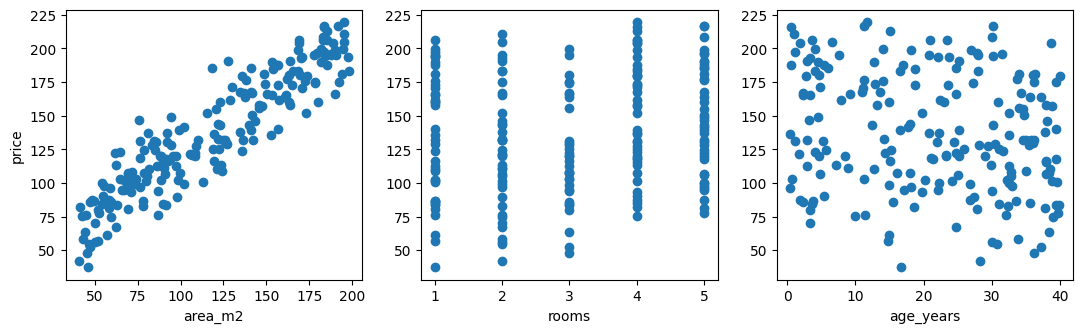

In [ ]:
plt.figure(figsize=(13, 3.5))

plt.subplot(1, 3, 1)
plt.scatter(houses["area_m2"], houses["price"])
plt.xlabel("area_m2")
plt.ylabel("price")

plt.subplot(1, 3, 2)
plt.scatter(houses["rooms"], houses["price"])
plt.xlabel("rooms")

plt.subplot(1, 3, 3)
plt.scatter(houses["age_years"], houses["price"])
plt.xlabel("age_years")

plt.show()

Area has the clearest relationship with price. Rooms and age also matter, but their effect is harder to see in a single plot. A model that uses all three features together can pick up all of these effects.

### Step 2: Separate features (X) and target (y)

- `X` holds the input columns. It is a table, so we use a capital letter.
- `y` holds the column we want to predict.

In [ ]:
X = houses[["area_m2", "rooms", "age_years"]]
y = houses["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 3)
y shape: (200,)


### Step 3: Split into training and test sets

We train the model on one part of the data and test it on another part that it has **never seen**. This tells us how the model will behave on new houses.

Here 80% of the rows go to training and 20% go to testing.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 160
Test rows: 40


### Step 4: Train the model

Two lines are enough: create the model, then call `fit` with the training data.

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model is trained.")

Model is trained.


### Step 5: Read the weights

The model has learned one weight per feature, plus an intercept.

In [ ]:
weights = pd.DataFrame({
    "feature": X.columns,
    "weight": model.coef_
})
print(weights)
print()
print("Intercept:", model.intercept_)

     feature    weight
0    area_m2  0.880642
1      rooms  8.245230
2  age_years -0.683617

Intercept: 22.89511504588978


**How to read these numbers**

Compare them with the true rule we used to create the data:

`price = 20 + 0.9 * area + 8 * rooms - 0.6 * age + noise`

The learned weights are close to 0.9, 8 and -0.6. They are not exactly equal because of the random noise.

- Each extra square metre adds about 0.9 thousand USD to the price.
- Each extra room adds about 8 thousand USD.
- Each extra year of age **reduces** the price by about 0.6 thousand USD (the weight is negative).

Each weight describes the effect of one feature **while the other features stay the same**.

### Step 6: Predict and measure the error

We use three measures:

| Measure | Meaning | Good value |
|---|---|---|
| MSE (mean squared error) | average of the squared errors | small |
| RMSE | square root of MSE, in the same unit as the target | small |
| R2 score | how much of the variation in the target the model explains | close to 1 |

In [ ]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 3))

MSE : 67.93
RMSE: 8.24
R2  : 0.963


The RMSE says that our predictions are wrong by roughly 8 thousand USD on average. That is about the size of the random noise we added (standard deviation 10), so the model is about as good as it can be on this data.

A useful picture: predicted price against actual price. If the model were perfect, every point would be on the diagonal line.

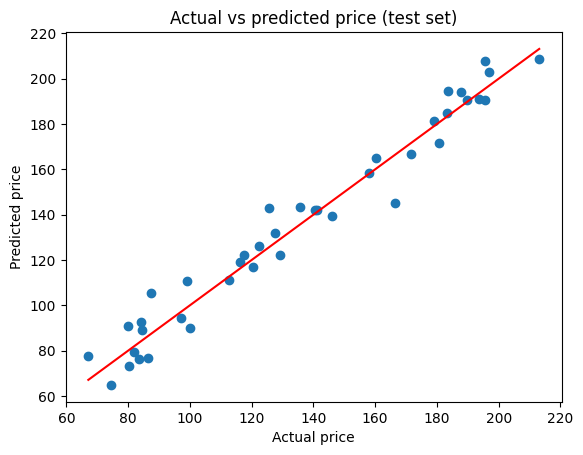

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs predicted price (test set)")
plt.show()

### Step 7: Predict the price of a new house

A new house: 100 square metres, 3 rooms, 10 years old. The new data must have the same columns, in the same order, as the training data.

In [ ]:
new_house = pd.DataFrame({
    "area_m2": [100],
    "rooms": [3],
    "age_years": [10]
})

predicted_price = model.predict(new_house)
print("Predicted price (thousand USD):", round(predicted_price[0], 1))

Predicted price (thousand USD): 128.9


## A2. Feature Scaling

### The problem

Our features live on very different scales.

In [ ]:
X_train.describe().loc[["min", "max", "mean", "std"]].round(1)

,area_m2,rooms,age_years
min,40.9,1.0,0.4
max,197.7,5.0,39.9
mean,117.1,3.0,20.6
std,47.2,1.5,12.7


`area_m2` has values around 100, while `rooms` has values around 3. This causes two problems:

1. **The weights cannot be compared.** The weight of `rooms` (about 8) is bigger than the weight of `area_m2` (about 0.9). That does not mean rooms are more important. The weights are in different units.
2. **Some training methods work badly.** Gradient descent, which is used to train many machine learning models, becomes slow or unstable when features have very different scales.

**Feature scaling** puts all features on a similar scale.

### Standardization

The most common method is **standardization**. For every value in a column:

$$z = \frac{x - \text{mean}}{\text{standard deviation}}$$

After standardization every column has mean 0 and standard deviation 1.

Let us do it by hand for the `area_m2` column first.

In [ ]:
area_train = X_train["area_m2"]

area_mean = np.mean(area_train)
area_std = np.std(area_train)

area_scaled = (area_train - area_mean) / area_std

print("Before scaling: mean =", round(area_mean, 2), " std =", round(area_std, 2))
print("After scaling : mean =", round(np.mean(area_scaled), 2), " std =", round(np.std(area_scaled), 2))
print()
print("First 5 values before:", area_train.values[:5].round(1))
print("First 5 values after :", area_scaled.values[:5].round(2))

Before scaling: mean = 117.1  std = 47.04
After scaling : mean = -0.0  std = 1.0

First 5 values before: [ 58.5 183.5 149.5 113.   90.9]
First 5 values after : [-1.24  1.41  0.69 -0.09 -0.56]


A scaled value of 0 means "an average house". A value of +1 means "one standard deviation bigger than average". A negative value means "smaller than average".

### StandardScaler

scikit-learn does the same thing for all columns at once with `StandardScaler`.

**Important rule:**

- Call `fit_transform` on the **training** data. The scaler learns the mean and standard deviation from the training data and scales it.
- Call only `transform` on the **test** data. It reuses the mean and standard deviation from the training data.

We never let the scaler learn from the test data, because the test data must stay unseen.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # learn mean and std from training data, then scale
X_test_scaled = scaler.transform(X_test)         # scale the test data with the SAME mean and std

print("Means learned from training data:", scaler.mean_.round(2))
print()
print("Mean of each scaled training column:", X_train_scaled.mean(axis=0).round(2))
print("Std of each scaled training column :", X_train_scaled.std(axis=0).round(2))

Means learned from training data: [117.1    3.04  20.64]

Mean of each scaled training column: [-0. -0. -0.]
Std of each scaled training column : [1. 1. 1.]


All three columns now have mean 0 and standard deviation 1.

### Another method: min-max scaling

Min-max scaling squeezes every column into the range 0 to 1:

$$x_{scaled} = \frac{x - \text{min}}{\text{max} - \text{min}}$$

In this lab we use standardization, but it is good to know both.

In [ ]:
minmax = MinMaxScaler()
X_train_minmax = minmax.fit_transform(X_train)

print("Smallest value in each column:", X_train_minmax.min(axis=0))
print("Largest value in each column :", X_train_minmax.max(axis=0))

Smallest value in each column: [0. 0. 0.]
Largest value in each column : [1. 1. 1.]


### Does scaling change the predictions of LinearRegression?

Let us train the same model again, this time on the scaled data.

In [ ]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

print("R2 without scaling:", round(r2_score(y_test, y_pred), 3))
print("R2 with scaling   :", round(r2_score(y_test, y_pred_scaled), 3))

R2 without scaling: 0.963
R2 with scaling   : 0.963


The R2 score is **the same**. scikit-learn's `LinearRegression` solves the problem with an exact formula, so scaling does not change its predictions.

What does change is the weights.

In [ ]:
compare = pd.DataFrame({
    "feature": X.columns,
    "weight without scaling": model.coef_.round(2),
    "weight with scaling": model_scaled.coef_.round(2)
})
compare

,feature,weight without scaling,weight with scaling
0,area_m2,0.88,41.43
1,rooms,8.25,11.93
2,age_years,-0.68,-8.62


After scaling, all weights are in the same unit ("change in price when the feature goes up by one standard deviation"). Now we **can** compare them:

- `area_m2` has by far the largest weight, so it has the strongest effect on price.
- Without scaling, `rooms` looked the most important only because of its unit.

### Where scaling really matters: gradient descent

Many models are trained with **gradient descent**. It works like this:

1. Start with all weights equal to 0.
2. Make predictions and measure the error (the cost).
3. Change the weights a little in the direction that makes the error smaller.
4. Repeat many times.

The size of each change is controlled by the **learning rate**.

Below is a short gradient descent function. You do not need to memorise it. Just know what goes in and what comes out:

- In: the features `X`, the target `y`, a learning rate and a number of steps.
- Out: the weights, the intercept, and a list with the cost (MSE) at every step.

In [ ]:
def gradient_descent(X, y, learning_rate, steps):
    X = np.array(X)
    y = np.array(y)
    n = X.shape[0]                 # number of rows
    w = np.zeros(X.shape[1])       # one weight per feature, all start at 0
    b = 0.0                        # intercept starts at 0
    costs = []

    for step in range(steps):
        y_pred = X.dot(w) + b              # 1. predict
        error = y_pred - y                 # 2. how wrong are we?
        costs.append(np.mean(error ** 2))  #    save the cost (MSE)

        # 3. move the weights and intercept a little to reduce the error
        w = w - learning_rate * (2 / n) * X.T.dot(error)
        b = b - learning_rate * (2 / n) * np.sum(error)

    return w, b, costs

**Experiment 1: unscaled data with a normal learning rate (0.01)**

We print the cost at each of the first 8 steps. The cost should go down.

In [ ]:
w1, b1, costs1 = gradient_descent(X_train, y_train, learning_rate=0.01, steps=8)

for i in range(len(costs1)):
    print("step", i, " cost:", costs1[i])

step 0  cost: 20718.34112479521
step 1  cost: 2134822064.3058586
step 2  cost: 225369696810865.0
step 3  cost: 2.379191812370224e+19
step 4  cost: 2.511674710562677e+24
step 5  cost: 2.6515347854174833e+29
step 6  cost: 2.7991828275819575e+34
step 7  cost: 2.955052502166607e+39


The cost does not go down. It **explodes**. The large values of `area_m2` make every step far too big, so the model jumps further and further away from the answer.

**Experiment 2: unscaled data with a very small learning rate (0.00001)**

To stop the explosion we must use a tiny learning rate.

In [ ]:
w2, b2, costs2 = gradient_descent(X_train, y_train, learning_rate=0.00001, steps=1000)

print("Cost after 1000 steps:", round(costs2[-1], 2))

Cost after 1000 steps: 450.88


It no longer explodes, but it learns very slowly. After 1000 steps the cost is still about 450. Experiment 3 will show that the best possible cost on this training data is about 107.

**Experiment 3: scaled data with learning rate 0.1**

In [ ]:
w3, b3, costs3 = gradient_descent(X_train_scaled, y_train, learning_rate=0.1, steps=1000)

print("Cost after 1000 steps:", round(costs3[-1], 2))
print()
print("Weights from gradient descent:", w3.round(2))
print("Weights from sklearn         :", model_scaled.coef_.round(2))

Cost after 1000 steps: 107.45

Weights from gradient descent: [41.43 11.93 -8.62]
Weights from sklearn         : [41.43 11.93 -8.62]


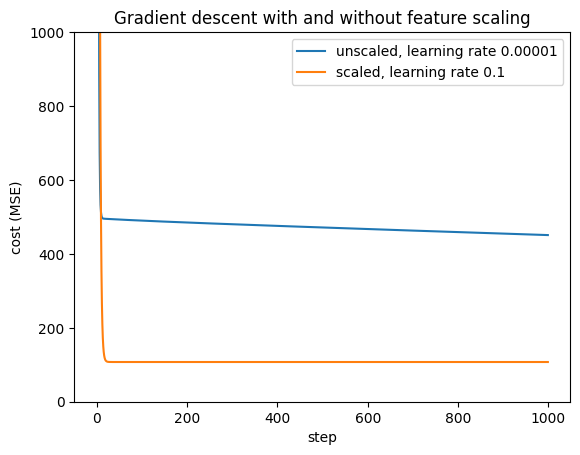

In [ ]:
plt.plot(costs2, label="unscaled, learning rate 0.00001")
plt.plot(costs3, label="scaled, learning rate 0.1")
plt.ylim(0, 1000)            # zoom in, because the very first costs are huge
plt.xlabel("step")
plt.ylabel("cost (MSE)")
plt.title("Gradient descent with and without feature scaling")
plt.legend()
plt.show()

With scaled features, gradient descent reaches the best cost within a few dozen steps and finds the same weights as scikit-learn.

**Summary of feature scaling**

| Question | Answer |
|---|---|
| What does it do? | Puts all features on a similar scale. |
| Does it change `LinearRegression` predictions? | No. |
| Why use it then? | Weights become comparable, and gradient descent becomes fast and stable. |
| How do we apply it? | `fit_transform` on training data, `transform` on test data. |

### Predicting a new house with the scaled model

The model was trained on scaled data, so new data must be scaled **with the same scaler** before predicting.

In [ ]:
new_house_scaled = scaler.transform(new_house)

print("Scaled features of the new house:", new_house_scaled.round(2))
print("Predicted price (thousand USD):", round(model_scaled.predict(new_house_scaled)[0], 1))

Scaled features of the new house: [[-0.36 -0.03 -0.84]]
Predicted price (thousand USD): 128.9


This is the same prediction as in Step 7.

## A3. Polynomial Regression

### The problem: not every relationship is a straight line

Example: the electricity a building uses each day depends on the outside temperature.

- On cold days the heating is on, so energy use is high.
- On mild days energy use is low.
- On hot days the air conditioning is on, so energy use is high again.

That gives a U-shaped curve. Let us create this data.

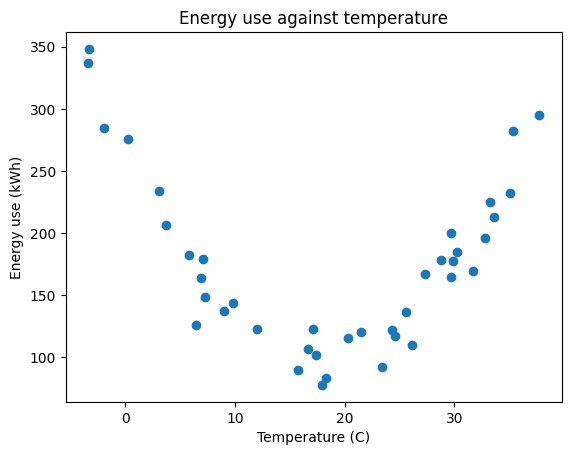

In [ ]:
np.random.seed(20)

temperature = np.random.uniform(-5, 40, 40)                             # degrees Celsius
energy = 0.5 * (temperature - 18) ** 2 + 100 + np.random.normal(0, 15, 40)   # kWh per day

plt.scatter(temperature, energy)
plt.xlabel("Temperature (C)")
plt.ylabel("Energy use (kWh)")
plt.title("Energy use against temperature")
plt.show()

### First try: a straight line

scikit-learn needs `X` as a table (rows and columns), even when there is only one feature. `reshape(-1, 1)` turns a list of numbers into a table with one column.

In [ ]:
X_temp = temperature.reshape(-1, 1)    # 40 rows, 1 column
y_energy = energy

print("Shape of X_temp:", X_temp.shape)

line_model = LinearRegression()
line_model.fit(X_temp, y_energy)

print("R2 of the straight line:", round(line_model.score(X_temp, y_energy), 3))

Shape of X_temp: (40, 1)
R2 of the straight line: 0.028


`model.score(X, y)` is a shortcut that makes predictions and returns the R2 score.

The R2 is close to 0, so the straight line explains almost nothing. The plot shows why.

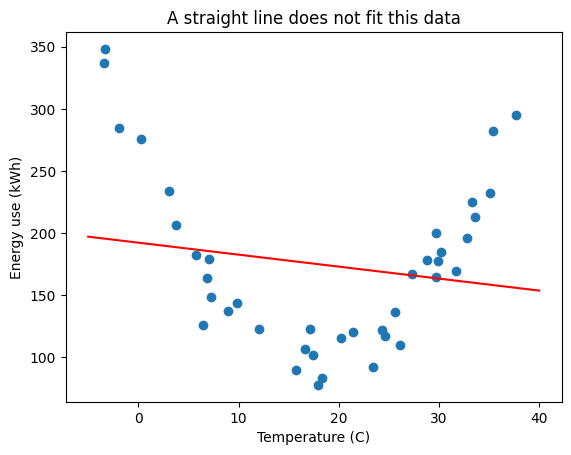

In [ ]:
# 100 evenly spaced temperatures, used to draw smooth lines
x_line = np.linspace(-5, 40, 100).reshape(-1, 1)

plt.scatter(temperature, energy)
plt.plot(x_line, line_model.predict(x_line), color="red")
plt.xlabel("Temperature (C)")
plt.ylabel("Energy use (kWh)")
plt.title("A straight line does not fit this data")
plt.show()

### The idea of polynomial regression

A straight line is $y = w_1 x + b$.

A curve (degree 2) is:

$$y = w_1 x + w_2 x^2 + b$$

Here is the trick: treat $x^2$ as **a new feature**. Then the model has two features, $x$ and $x^2$, and it is just multiple linear regression again, exactly like section A1.

So polynomial regression has two steps:

1. Create the new features ($x^2$, $x^3$, ...).
2. Train an ordinary linear regression on them.

`PolynomialFeatures` does step 1 for us.

In [ ]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_temp_poly2 = poly2.fit_transform(X_temp)

print("Shape before:", X_temp.shape)
print("Shape after :", X_temp_poly2.shape)
print()
print("First 5 rows (columns are x and x squared):")
print(X_temp_poly2[:5].round(1))

Shape before: (40, 1)
Shape after : (40, 2)

First 5 rows (columns are x and x squared):
[[  21.5  460.8]
 [  35.4 1253. ]
 [  35.1 1233.3]
 [  31.7 1005.7]
 [  -3.4   11.5]]


The second column is the first column squared. Now we train a linear regression on these two columns.

In [ ]:
curve_model = LinearRegression()
curve_model.fit(X_temp_poly2, y_energy)

print("R2 of the straight line :", round(line_model.score(X_temp, y_energy), 3))
print("R2 of the degree 2 curve:", round(curve_model.score(X_temp_poly2, y_energy), 3))

R2 of the straight line : 0.028
R2 of the degree 2 curve: 0.944


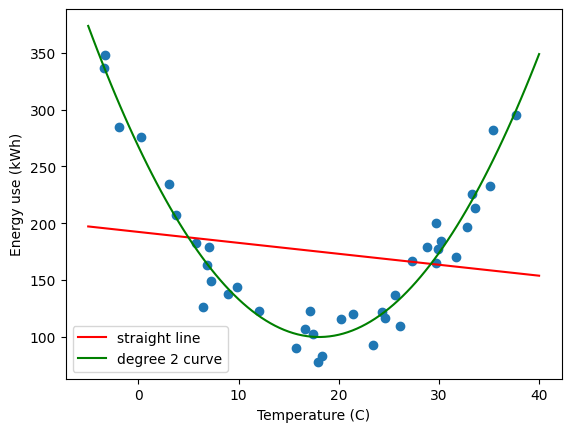

In [ ]:
# To draw the curve, the plotting points need the same new feature (x squared)
x_line_poly2 = poly2.transform(x_line)

plt.scatter(temperature, energy)
plt.plot(x_line, line_model.predict(x_line), color="red", label="straight line")
plt.plot(x_line, curve_model.predict(x_line_poly2), color="green", label="degree 2 curve")
plt.xlabel("Temperature (C)")
plt.ylabel("Energy use (kWh)")
plt.legend()
plt.show()

The degree 2 curve follows the U shape and the R2 score jumps from almost 0 to above 0.9.

### Polynomial features need scaling

Powers make numbers grow very quickly. Look at the ranges when we go up to degree 3.

In [ ]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_temp_poly3 = poly3.fit_transform(X_temp)

table = pd.DataFrame(X_temp_poly3, columns=["x", "x^2", "x^3"])
table.describe().loc[["min", "max"]].round(0)

,x,x^2,x^3
min,-3.0,0.0,-39.0
max,38.0,1424.0,53754.0


`x` goes up to about 40, but `x^3` goes up to tens of thousands. These are exactly the "very different scales" from section A2, and it gets worse with every extra degree.

So the standard recipe for polynomial regression has **three steps**:

1. `PolynomialFeatures` creates the new features.
2. `StandardScaler` scales them.
3. `LinearRegression` learns the weights.

### Choosing the degree

A higher degree makes the curve more flexible. Is a higher degree always better? We test it properly, with a training set and a test set.

In [ ]:
Xt_train, Xt_test, yt_train, yt_test = train_test_split(X_temp, y_energy, test_size=0.3, random_state=0)

for d in [1, 2, 3, 5, 10, 15]:
    # step 1: create polynomial features
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xp_train = poly.fit_transform(Xt_train)
    Xp_test = poly.transform(Xt_test)

    # step 2: scale them
    sc = StandardScaler()
    Xs_train = sc.fit_transform(Xp_train)
    Xs_test = sc.transform(Xp_test)

    # step 3: train linear regression
    m = LinearRegression()
    m.fit(Xs_train, yt_train)

    print("degree", d, "  train R2:", round(m.score(Xs_train, yt_train), 3),
          "  test R2:", round(m.score(Xs_test, yt_test), 3))

degree 1   train R2: 0.0   test R2: -0.019
degree 2   train R2: 0.921   test R2: 0.971
degree 3   train R2: 0.921   test R2: 0.97
degree 5   train R2: 0.928   test R2: 0.924
degree 10   train R2: 0.937   test R2: 0.754
degree 15   train R2: 0.955   test R2: -4246.913


**How to read this table**

- **Degree 1:** both scores are bad. The model is too simple. This is called **underfitting**. (An R2 below 0 on the test set means the model is worse than simply predicting the average every time.)
- **Degree 2:** both scores are high. This is a good model.
- **High degrees:** the training score keeps creeping up, but the test score gets worse and worse. The model starts to memorise the noise in the training data instead of learning the real pattern. This is called **overfitting**.

**Rule:** choose the degree with the best **test** score, not the best training score. If two degrees are almost equal, choose the smaller one.

The plot below shows what the three situations look like.

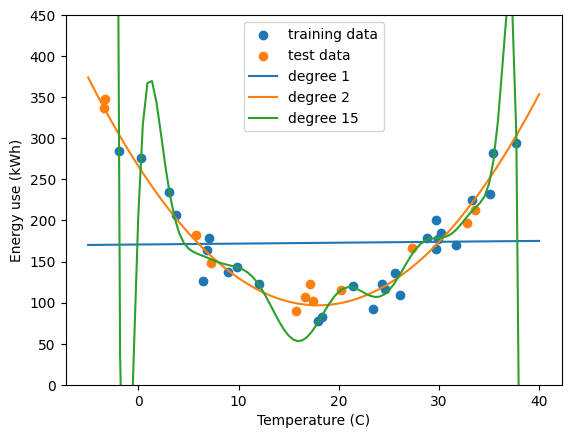

In [ ]:
plt.scatter(Xt_train, yt_train, label="training data")
plt.scatter(Xt_test, yt_test, label="test data")

for d in [1, 2, 15]:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    sc = StandardScaler()
    m = LinearRegression()

    m.fit(sc.fit_transform(poly.fit_transform(Xt_train)), yt_train)
    y_line = m.predict(sc.transform(poly.transform(x_line)))

    plt.plot(x_line, y_line, label="degree " + str(d))

plt.ylim(0, 450)
plt.xlabel("Temperature (C)")
plt.ylabel("Energy use (kWh)")
plt.legend()
plt.show()

The degree 15 curve follows the training points closely, but it swings wildly near the edges of the data, where there are only a few training points. It scores well on the training data but it is unreliable for new data.

## A4. Summary of Part A

| Topic | Key point |
|---|---|
| Multiple linear regression | One weight per feature: $y = w_1 x_1 + w_2 x_2 + ... + b$ |
| Workflow | select X and y, split, fit, predict, evaluate |
| Evaluation | MSE and RMSE should be small, R2 should be close to 1 |
| Feature scaling | `fit_transform` on train, `transform` on test |
| Why scale | comparable weights, stable gradient descent, needed for polynomial features |
| Polynomial regression | create powers of x, then run linear regression |
| Choosing a degree | too low underfits, too high overfits; trust the test score |

**Common mistakes to avoid**

1. Calling `fit_transform` on the test data. Use only `transform`.
2. Forgetting to scale new data before predicting with a model trained on scaled data.
3. Choosing the polynomial degree by the training score.
4. Passing a 1-D list as `X`. Use `reshape(-1, 1)` or double brackets `df[["column"]]`.

---
# Part B: Graded Exercises (100 marks)

Work on your own. You may look back at Part A at any time.

**Rules**

- Write your code in the empty cell under each task.
- Use the variable names given in the task. Later tasks depend on them.
- For written questions, double-click the "Your answer" cell and type your answer. Two or three sentences are enough.
- Before you submit, use *Runtime > Restart and run all* and check that there are no errors.

**Student name:**

**Student ID:**

| Exercise | Topic | Marks |
|---|---|---|
| 1 | Exploring and preparing the data | 15 |
| 2 | Multiple linear regression | 20 |
| 3 | Feature scaling | 25 |
| 4 | Polynomial regression | 25 |
| 5 | Choosing the polynomial degree | 15 |
| | **Total** | **100** |

## B0. Setup for Part B

Run the cell below once. **Do not change it.** It imports the libraries, creates the two datasets, and repeats the `gradient_descent` function from Part A, so Part B works even if you restart the notebook.

**Dataset 1: `cars`** (used car prices, 300 cars)

| Column | Meaning |
|---|---|
| `mileage_km` | distance the car has driven, in km |
| `age_years` | age of the car in years |
| `engine_l` | engine size in litres |
| `price_usd` | selling price in USD (the target) |

**Dataset 2: `crops`** (a farming experiment, 40 fields)

| Column | Meaning |
|---|---|
| `fertilizer_kg` | fertilizer used per hectare, in kg |
| `yield_tons` | crop yield in tons per hectare (the target) |

In [1]:
# ---------- DO NOT CHANGE THIS CELL ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(7)

# Dataset 1: used cars
n_cars = 300
mileage = np.random.uniform(5000, 250000, n_cars)
car_age = np.random.uniform(0, 20, n_cars)
engine = np.random.uniform(1.0, 3.5, n_cars)
car_price = 25000 - 0.05 * mileage - 600 * car_age + 4000 * engine + np.random.normal(0, 1500, n_cars)

cars = pd.DataFrame({
    "mileage_km": mileage.round(0),
    "age_years": car_age.round(1),
    "engine_l": engine.round(1),
    "price_usd": car_price.round(0)
})

# Dataset 2: fertilizer and crop yield
n_fields = 40
fertilizer = np.random.uniform(0, 200, n_fields)
crop_yield = 2.0 + 0.06 * fertilizer - 0.0003 * fertilizer ** 2 + np.random.normal(0, 0.3, n_fields)

crops = pd.DataFrame({
    "fertilizer_kg": fertilizer.round(1),
    "yield_tons": crop_yield.round(2)
})


# Gradient descent function from Part A
def gradient_descent(X, y, learning_rate, steps):
    X = np.array(X)
    y = np.array(y)
    n = X.shape[0]
    w = np.zeros(X.shape[1])
    b = 0.0
    costs = []
    for step in range(steps):
        y_pred = X.dot(w) + b
        error = y_pred - y
        costs.append(np.mean(error ** 2))
        w = w - learning_rate * (2 / n) * X.T.dot(error)
        b = b - learning_rate * (2 / n) * np.sum(error)
    return w, b, costs


print("Setup complete.")
print("cars :", cars.shape)
print("crops:", crops.shape)

Setup complete.
cars : (300, 4)
crops: (40, 2)


---
## Exercise 1: Exploring and preparing the data (15 marks)

Use the `cars` dataset.

**Task 1.1 (3 marks)** Show the first 5 rows of `cars` and print its shape.

In [2]:
# Task 1.1
print(cars.head())
print("Shape:", cars.shape)


   mileage_km  age_years  engine_l  price_usd
0     23696.0       18.8       3.0    25990.0
1    196080.0        9.4       1.6    16645.0
2    112410.0        0.1       2.2    27641.0
3    182249.0       20.0       2.3    15157.0
4    244607.0        1.0       3.1    24856.0
Shape: (300, 4)


**Task 1.2 (3 marks)** Show the summary statistics of `cars` with `describe()`.

In [ ]:
# Task 1.2
print(cars.describe())


          mileage_km   age_years    engine_l     price_usd
count     300.000000  300.000000  300.000000    300.000000
mean   125334.436667   10.068333    2.238333  21722.000000
std     71386.300465    5.924850    0.708027   5766.957176
min      5350.000000    0.100000    1.000000   8818.000000
25%     63795.750000    5.000000    1.600000  17576.750000
50%    121762.500000    9.700000    2.250000  21766.500000
75%    189324.750000   15.725000    2.900000  25832.000000
max    248177.000000   20.000000    3.500000  37332.000000


**Task 1.3 (3 marks)** Look at the output of Task 1.2. Which feature has the largest range of values and which has the smallest? Why could this be a problem?

**Your answer:**

`mileage_km` has the largest range, while `engine_l` has the smallest range. Different feature scales can make some features dominate calculations and can make gradient descent converge slowly or become unstable.


**Task 1.4 (6 marks)**

1. Create `X_cars` with the three feature columns `mileage_km`, `age_years`, `engine_l`.
2. Create `y_cars` with the target column `price_usd`.
3. Split them into `X_train`, `X_test`, `y_train`, `y_test`. Use `test_size=0.2` and `random_state=1`.
4. Print the shapes of `X_train` and `X_test`.

In [ ]:
# Task 1.4
X_cars = cars[["mileage_km", "age_years", "engine_l"]]
y_cars = cars["price_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cars, y_cars, test_size=0.2, random_state=1
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (240, 3)
X_test shape: (60, 3)


---
## Exercise 2: Multiple linear regression (20 marks)

**Task 2.1 (6 marks)** Create a `LinearRegression` model called `model_cars` and train it on `X_train` and `y_train`. Print the weight of each feature and the intercept.

In [ ]:
# Task 2.1
model_cars = LinearRegression()
model_cars.fit(X_train, y_train)

print("Weights:")
for feature, weight in zip(X_train.columns, model_cars.coef_):
    print(feature, ":", weight)

print("Intercept:", model_cars.intercept_)


Weights:
mileage_km : -0.050181025242221816
age_years : -583.6998953835077
engine_l : 4028.7082319920255
Intercept: 24938.370766208463


**Task 2.2 (6 marks)** Predict the prices of the test set and store them in `y_pred`. Print the MSE, the RMSE and the R2 score.

In [ ]:
# Task 2.2
y_pred = model_cars.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MSE: 2215829.526732639
RMSE: 1488.566265482541
R2: 0.9352718662538462


**Task 2.3 (4 marks)** Predict the price of a car with 80,000 km, 5 years old, with a 2.0 litre engine.

In [ ]:
# Task 2.3
new_car = pd.DataFrame({
    "mileage_km": [80000],
    "age_years": [5],
    "engine_l": [2.0]
})

predicted_price = model_cars.predict(new_car)[0]
print("Predicted price: $", round(predicted_price, 2))


Predicted price: $ 26062.81


**Task 2.4 (4 marks)**

(a) Explain in one sentence what the weight of `age_years` means.

(b) `engine_l` has the largest weight and `mileage_km` has a weight very close to 0. Does this mean mileage is not important for the price? Explain.

**Your answer:**

(a) The weight of `age_years` is about -584, meaning that, while the other features are held constant, one additional year of car age is associated with about a $584 decrease in predicted price.

(b) No. The size of an unscaled weight depends on the units of the feature, so a small mileage coefficient is expected because mileage is measured in thousands of kilometres. Mileage can still have a strong effect on price; its contribution depends on both the coefficient and the size of the feature values.


---
## Exercise 3: Feature scaling (25 marks)

**Task 3.1 (5 marks)** Standardize the `mileage_km` column of `X_train` **by hand**, using the formula

`scaled = (value - mean) / standard deviation`

Store the result in `mileage_scaled`. Print the mean and the standard deviation of `mileage_scaled`, rounded to 2 decimals.

In [ ]:
# Task 3.1
mileage_mean = X_train["mileage_km"].mean()
mileage_std = X_train["mileage_km"].std()

mileage_scaled = (X_train["mileage_km"] - mileage_mean) / mileage_std

print("Mean:", round(mileage_scaled.mean(), 2))
print("Standard deviation:", round(mileage_scaled.std(), 2))


Mean: 0.0
Standard deviation: 1.0


**Task 3.2 (6 marks)** Use `StandardScaler` to scale all features.

- Create a scaler called `scaler_cars`.
- Create `X_train_s` from `X_train` and `X_test_s` from `X_test`.
- Print the mean of each column of `X_train_s`, rounded to 2 decimals.

Be careful to use the correct method for the training data and for the test data.

In [ ]:
# Task 3.2
scaler_cars = StandardScaler()

X_train_s = scaler_cars.fit_transform(X_train)
X_test_s = scaler_cars.transform(X_test)

print("Training means:", np.mean(X_train_s, axis=0).round(2))


Training means: [ 0. -0.  0.]


**Task 3.3 (6 marks)** Train a new `LinearRegression` model called `model_cars_s` on the scaled training data. Print its weights and its R2 score on the scaled test data.

In [ ]:
# Task 3.3
model_cars_s = LinearRegression()
model_cars_s.fit(X_train_s, y_train)

r2_scaled = model_cars_s.score(X_test_s, y_test)

print("Scaled weights:", model_cars_s.coef_)
print("R2 on scaled test data:", r2_scaled)


Scaled weights: [-3584.57340311 -3386.89310128  2849.79448824]
R2 on scaled test data: 0.9352718662543568


**Task 3.4 (4 marks)** Use the `gradient_descent` function twice with `learning_rate=0.1`:

1. on the **unscaled** data `X_train`, `y_train` with `steps=5`
2. on the **scaled** data `X_train_s`, `y_train` with `steps=200`

For each run, print the last cost in the list of costs. (The last item of a list called `costs` is `costs[-1]`.)

In [ ]:
# Task 3.4
w_unscaled, b_unscaled, costs_unscaled = gradient_descent(
    X_train, y_train, learning_rate=0.1, steps=5
)
print("Last cost (unscaled):", costs_unscaled[-1])

w_scaled, b_scaled, costs_scaled = gradient_descent(
    X_train_s, y_train, learning_rate=0.1, steps=200
)
print("Last cost (scaled):", costs_scaled[-1])


Last cost (unscaled): 2.335430303482859e+85
Last cost (scaled): 1867684.573628036


**Task 3.5 (4 marks)**

(a) Compare the R2 from Task 2.2 with the R2 from Task 3.3. What do you notice, and why?

(b) Look at the weights from Task 3.3. Which feature has the strongest effect on the price now? Is this different from what the unscaled weights suggested?

(c) What happened to gradient descent on the unscaled data in Task 3.4, and why?

**Your answer:**

(a) The R2 scores are essentially the same. Feature scaling changes the units of the features, not the underlying information, so ordinary linear regression gives the same predictive performance.

(b) After scaling, the weights are directly comparable because all features are measured in standard-deviation units. `mileage_km` has the strongest effect in magnitude, so its standardized effect is larger than the others.

(c) Gradient descent on the unscaled data makes extremely large jumps because `mileage_km` has values in the hundreds of thousands while the learning rate is 0.1. The cost therefore grows dramatically instead of decreasing. Scaling puts the features on comparable ranges and makes gradient descent much more stable.


---
## Exercise 4: Polynomial regression (25 marks)

Use the `crops` dataset.

**Task 4.1 (4 marks)** Draw a scatter plot with `fertilizer_kg` on the x-axis and `yield_tons` on the y-axis. Add axis labels and a title.

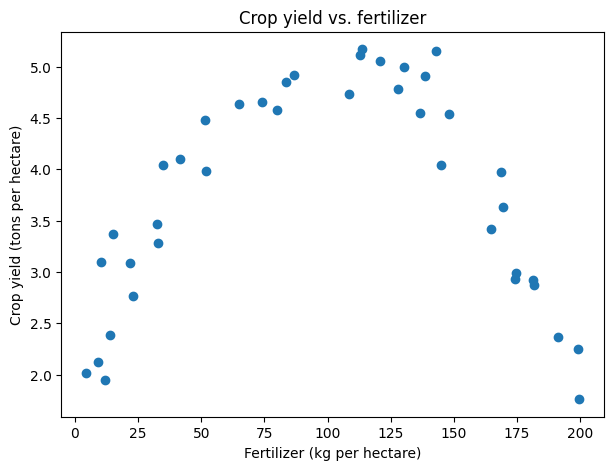

In [ ]:
# Task 4.1
plt.figure(figsize=(7, 5))
plt.scatter(crops["fertilizer_kg"], crops["yield_tons"])
plt.xlabel("Fertilizer (kg per hectare)")
plt.ylabel("Crop yield (tons per hectare)")
plt.title("Crop yield vs. fertilizer")
plt.show()


**Task 4.2 (6 marks)**

1. Create `X_crop = crops[["fertilizer_kg"]]` (double brackets, so it is a table) and `y_crop = crops["yield_tons"]`.
2. Split into `Xc_train`, `Xc_test`, `yc_train`, `yc_test` with `test_size=0.25` and `random_state=24`.
3. Train a straight-line `LinearRegression` model called `line_crop` and print its R2 score on the test set.

In [ ]:
# Task 4.2
X_crop = crops[["fertilizer_kg"]]
y_crop = crops["yield_tons"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_crop, y_crop, test_size=0.25, random_state=24
)

line_crop = LinearRegression()
line_crop.fit(Xc_train, yc_train)

print("Straight-line test R2:", line_crop.score(Xc_test, yc_test))


Straight-line test R2: -0.3725397232810006


**Task 4.3 (8 marks)** Build a degree 2 polynomial regression using the three steps from Part A:

1. `PolynomialFeatures(degree=2, include_bias=False)` to create the features.
2. `StandardScaler` to scale them.
3. `LinearRegression` to train. Call the model `curve_crop`.

Remember: `fit_transform` on the training data, `transform` on the test data. Print the R2 score on the test set.

In [ ]:
# Task 4.3
poly_crop = PolynomialFeatures(degree=2, include_bias=False)

Xc_train_poly = poly_crop.fit_transform(Xc_train)
Xc_test_poly = poly_crop.transform(Xc_test)

scaler_crop = StandardScaler()
Xc_train_poly_s = scaler_crop.fit_transform(Xc_train_poly)
Xc_test_poly_s = scaler_crop.transform(Xc_test_poly)

curve_crop = LinearRegression()
curve_crop.fit(Xc_train_poly_s, yc_train)

print("Degree 2 test R2:", curve_crop.score(Xc_test_poly_s, yc_test))


Degree 2 test R2: 0.9230798595070814


**Task 4.4 (4 marks)** Plot the data as a scatter plot and draw your degree 2 curve on top of it.

Hint: the first line is given. `x_line` holds 100 evenly spaced fertilizer values. Before predicting, pass `x_line` through the **same** polynomial transformer and the **same** scaler you used in Task 4.3 (use `transform`).

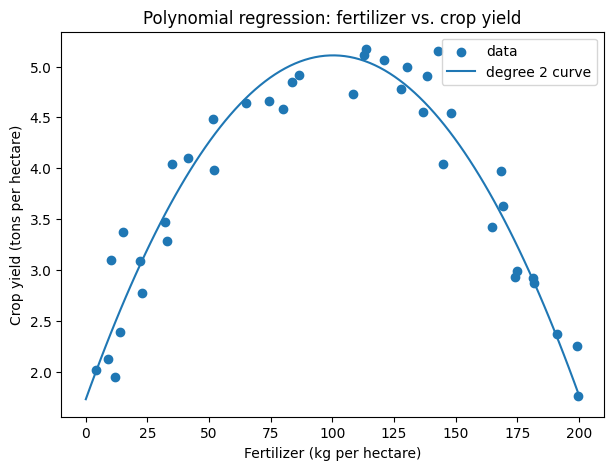

In [ ]:
# Task 4.4
x_line = pd.DataFrame({"fertilizer_kg": np.linspace(0, 200, 100)})

x_line_poly = poly_crop.transform(x_line)
x_line_poly_s = scaler_crop.transform(x_line_poly)
y_line = curve_crop.predict(x_line_poly_s)

plt.figure(figsize=(7, 5))
plt.scatter(crops["fertilizer_kg"], crops["yield_tons"], label="data")
plt.plot(x_line["fertilizer_kg"], y_line, label="degree 2 curve")
plt.xlabel("Fertilizer (kg per hectare)")
plt.ylabel("Crop yield (tons per hectare)")
plt.title("Polynomial regression: fertilizer vs. crop yield")
plt.legend()
plt.show()


**Task 4.5 (3 marks)** Compare the R2 scores from Task 4.2 and Task 4.3. Why does the degree 2 model work so much better than the straight line on this data? Use what you see in the scatter plot.

**Your answer:**

The degree 2 model works much better because the scatter plot follows a curved, roughly inverted-U-shaped relationship: yield increases with fertilizer at first and then starts to decrease. A straight line cannot represent this turning point, while a quadratic polynomial can.


---
## Exercise 5: Choosing the polynomial degree (15 marks)

Keep using `Xc_train`, `Xc_test`, `yc_train`, `yc_test` from Exercise 4.

**Task 5.1 (8 marks)** Write a `for` loop over the degrees `[1, 2, 3, 4, 6, 8, 10, 12]`. For each degree:

1. create polynomial features,
2. scale them,
3. train a `LinearRegression` model,
4. print the degree, the training R2 and the test R2 (rounded to 3 decimals).

Also save the scores: the two empty lists `train_scores` and `test_scores` are given. Inside the loop, add each score with `.append(...)`.

In [ ]:
# Task 5.1
degrees = [1, 2, 3, 4, 6, 8, 10, 12]
train_scores = []
test_scores = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)

    Xp_train = poly.fit_transform(Xc_train)
    Xp_test = poly.transform(Xc_test)

    scaler = StandardScaler()
    Xs_train = scaler.fit_transform(Xp_train)
    Xs_test = scaler.transform(Xp_test)

    model = LinearRegression()
    model.fit(Xs_train, yc_train)

    train_r2 = model.score(Xs_train, yc_train)
    test_r2 = model.score(Xs_test, yc_test)

    train_scores.append(train_r2)
    test_scores.append(test_r2)

    print("degree", d,
          " train R2:", round(train_r2, 3),
          " test R2:", round(test_r2, 3))


degree 1  train R2: 0.051  test R2: -0.373
degree 2  train R2: 0.91  test R2: 0.923
degree 3  train R2: 0.915  test R2: 0.894
degree 4  train R2: 0.915  test R2: 0.892
degree 6  train R2: 0.922  test R2: 0.89
degree 8  train R2: 0.925  test R2: 0.882
degree 10  train R2: 0.929  test R2: 0.764
degree 12  train R2: 0.929  test R2: 0.772


**Task 5.2 (3 marks)** Draw one line plot with the degree on the x-axis, showing the training R2 and the test R2 as two lines. Add axis labels and a legend.

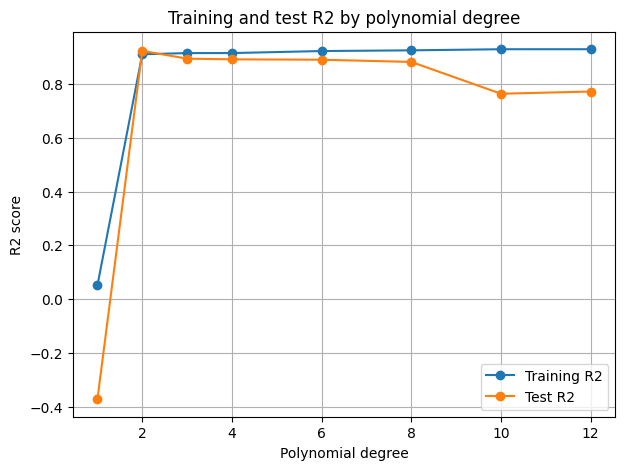

In [ ]:
# Task 5.2
plt.figure(figsize=(7, 5))
plt.plot(degrees, train_scores, marker="o", label="Training R2")
plt.plot(degrees, test_scores, marker="o", label="Test R2")
plt.xlabel("Polynomial degree")
plt.ylabel("R2 score")
plt.title("Training and test R2 by polynomial degree")
plt.legend()
plt.grid(True)
plt.show()


**Task 5.3 (4 marks)**

(a) Which degree would you choose for this data? Give your reason.

(b) Describe what happens to the training R2 and to the test R2 as the degree becomes large. What is this effect called?

**Your answer:**

(a) I would choose degree 3 because it gives the highest test R2 (about 0.754) among the tested degrees. It performs slightly better on unseen test data than degree 2 while remaining much simpler than the high-degree models.

(b) As the degree becomes large, the training R2 generally increases because the model becomes more flexible and can fit the training data more closely. The test R2 eventually decreases, which is called **overfitting**: the model starts fitting noise in the training data instead of learning the general relationship.
